# Introduction to Climate Data Analysis with xarray

## Learning Objectives
By the end of this notebook, you will be able to:
- Open and load NetCDF climate data files using xarray
- Understand the structure of xarray Datasets and DataArrays
- Apply rolling window operations to calculate multi-day precipitation metrics

---

## Part 1: Loading Climate Data

### What is NetCDF?
NetCDF (Network Common Data Form) is the standard file format (file extension `.nc`) for storing climate and meteorological data. These files contain multidimensional arrays (typically defined by time, latitude, and longitude) along with metadata describing the variables, coordinates, and measurement units.

### What is xarray?
Xarray is a Python library specifically designed for working with multidimensional arrays. It makes complex climate datasets easier to manipulate by keeping track of dimension names, coordinates, and metadata automatically. It also contains useful statistical and visualization methods that we will leverage to analyze our data.

The package is well-developed and features robust documentation, which you can view [here](https://docs.xarray.dev/en/stable/getting-started-guide/quick-overview.html).

First, we'll make sure we have the right Python libraries installed using `pip install`

In [1]:
!pip install xarray
!pip install netCDF4
!pip install numpy==1.26.4

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/opt/apps/intel19/python3/3.9.7/bin/python3.9 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/opt/apps/intel19/python3/3.9.7/bin/python3.9 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/opt/apps/intel19/python3/3.9.7/bin/python3.9 -m pip install --upgrade pip' command.


Next, let's import the `xarray` and `netCDF` libraries that we just installed and call the `open_dataset` function to open some data:

In [2]:
import xarray as xr
import netCDF4
%matplotlib inline

path_to_ds = "/scratch/07644/oxygen/GEO371T_Post_Processed/MSWEP-gauge-obs_pr_texas_1979-2024.nc"
pr_mswep_obs = xr.open_dataset(path_to_ds)

pr_mswep_obs

/home1/07999/gpersad/.local/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


<xarray.Dataset> Size: 930MB
Dimensions:        (time: 16741, lat: 106, lon: 131)
Coordinates:
  * lon            (lon) float32 524B -106.5 -106.4 -106.3 ... -93.65 -93.55
  * lat            (lat) float32 424B 36.45 36.35 36.25 ... 26.15 26.05 25.95
  * time           (time) datetime64[ns] 134kB 1979-01-01 ... 2024-11-02
Data variables:
    precipitation  (time, lat, lon) float32 930MB ...
Attributes:
    history:          Created on 2025-08-19 19:36
    input_data_hash:  28ef4bbc997638eed6d4581fd560b3c6803db32c638f228fa0864a5...

Notice how xarray creates a useful interface in our notebook for exploring the dataset structure and metadata. This is extremely helpful for getting a sense of the data before attempting to analyze it.

## Part 2: Exploring the data. What is MSWEP?

[Multi-Source Weighted-Ensemble Precipitation](https://www.gloh2o.org/)

> MSWEP provides hourly 0.1° resolution precipitation data from 1979 to the present with a 2‑hour delay. MSWEP leverages machine learning to merge and bias-correct satellite and model data.

There are three variants of MSWEP data:

> The ‘Past’ and ‘Past_nogauge’ variants represent the historical satellite-model merged data, with the ‘Past’ variant including gauge corrections and the ‘Past_nogauge’ variant excluding them. The ‘NRT’ variant extends the historical record to near real-time, with a latency of approximately 3 hours. For performance evaluations using gauge observations, we recommend the ‘Past_nogauge’ variant, while the ‘Past’ variant is more suitable for general use.

For the xarray structure above, we are evaluating the "Past", or what were are calling the `gauge`, dataset. To improve performance, we post-processed the raw NetCDF files and cropped the original global data to just the state of Texas. We can use xarray to visualize the spatial distribution by calling `.plot()`.

We can also immediately call the figure axis that this generates and add a title using `axes.set_title()`

Let's take a look at the spatial distribution of precipitation averaged over time by the use of `.mean(dim="time")`:

Text(0.5, 1.0, 'MSWEP Average Daily Precipitation (1979-2024)')

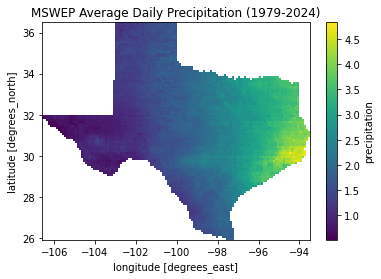

In [11]:
pr_mswep_obs["precipitation"].mean(dim="time").plot().axes.set_title("MSWEP Average Daily Precipitation (1979-2024)")

Notice how we can chain multiple xarray functions to together. Here, we calculate using `.mean` and then visualize using `.plot`. This is the mean of MSWEP observed precipitation over time from 1979 to 2024. 

### Example: 2013 Halloween Flood

Now, let's look at a historical 2013 Halloween Flood which happened on `2013-10-31`. We can use `.sel` to select that particular time slice in the dataset:

Text(0.5, 1.0, 'MSWEP 2013 Halloween Flood 1-day Precipitation')

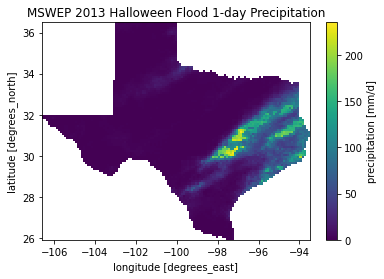

In [12]:
pr_mswep_obs["precipitation"].sel(time="2013-10-31").plot().axes.set_title("MSWEP 2013 Halloween Flood 1-day Precipitation")

Wow! That is a lot more precipitation than the average day (for reference, 200 mm is 7.8 inches). You can read more about the 2013 Halloween Flood [here](https://data.austintexas.gov/stories/s/2013-Halloween-Flood/fr92-dkxr/).

### Example: Hurricane Harvey

Now, let's look at another major flooding event: [Hurricane Harvey](https://www.weather.gov/crp/hurricane_harvey), which made landfall late in the evening on `08-25-2017` and had lasting impacts on the Texas Coastal region. Let's look at precipitation on the day that followed landfall, `08-26-2017`:

Text(0.5, 1.0, 'MSWEP Hurricane Harvey 1-day Precipitation (August 26, 2017)')

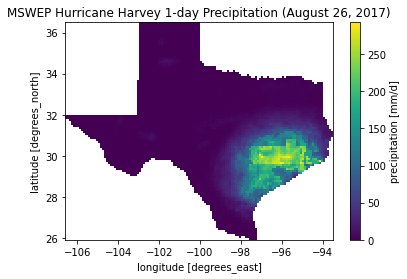

In [13]:
pr_mswep_obs["precipitation"].sel(time="08-26-2017").plot().axes.set_title("MSWEP Hurricane Harvey 1-day Precipitation (August 26, 2017)")

## Part 3: Deriving Precipitation Metrics

To evaluate droughts and floods, we need to derive metrics that capture the accumulation of rainfall beyond one-day precipitation measurements. We can derive some fundamental precipitation metrics by using the `.rolling` and `.sum` functions to calculate accumulate precipitation over 3-day and 5-day rolling windows: 

In [6]:
pr_metrics_mswep_obs = xr.Dataset(
    data_vars=dict(
        one_day_pr=pr_mswep_obs["precipitation"],
        three_day_pr=pr_mswep_obs["precipitation"].rolling(time=3, center=False).sum(),
        five_day_pr=pr_mswep_obs["precipitation"].rolling(time=5, center=False).sum()
    )
)
pr_metrics_mswep_obs["three_day_pr"].attrs["units"] = "mm/3day"
pr_metrics_mswep_obs["five_day_pr"].attrs["units"] = "mm/5day"

Therefore, a value of `three_day_pr` for one point in time is the sum of the past 3 days of precipitation. Notice how we also change the units to reflect the calculation. It is good practice to update metadata to keep your data organized. 

Revisiting Hurricane Harvey, let's look at precipitation accumulation three days after Harvey made landfall `08-28-2017`:

Text(0.5, 1.0, 'MSWEP Hurricane Harvey 3-day Precipitation (August 26-28, 2017)')

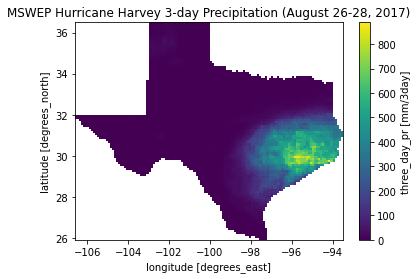

In [14]:
pr_metrics_mswep_obs["three_day_pr"].sel(time="08-28-2017").plot().axes.set_title("MSWEP Hurricane Harvey 3-day Precipitation (August 26-28, 2017)")

Now let's try the same comparison for the 2013 Halloween Flood in Austin:

Text(0.5, 1.0, 'MSWEP 2013 Halloween Flood 3-day Precipitation (Oct 31-Nov 2, 2013)')

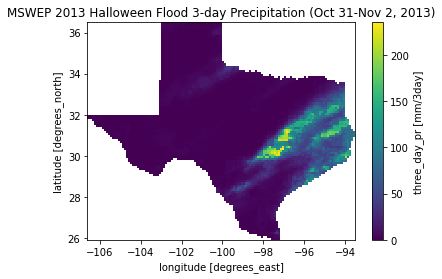

In [16]:
pr_metrics_mswep_obs["three_day_pr"].sel(time="2013-11-2").plot().axes.set_title("MSWEP 2013 Halloween Flood 3-day Precipitation (Oct 31-Nov 2, 2013)")

## TASK

#### In this markdown box, address the following:
- Describe the differences between the 1-day and 3-day maps of precipitation for Hurricane Harvey
- Describe the differences between the 1-day and 3-day maps of precipitation for the 2013 Halloween Floods
- Given what you understand about the drivers of these two events, discuss the difference in the behavior of the two events across the two precipitation metrics and why this difference might occur.